In [1]:
print("dd")

dd


In [2]:
!pip install numpy pandas

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.6 MB 3.4 MB/s eta 0:00:04
   - -------------------------------------- 0.5/12.6 MB 8.1 MB/s eta 0:00:02
   ---- ----------------------------------- 1.3/12.6 MB 11.8 MB/s eta 0:00:01
   ------ --------------------------------- 2.2/12.6 MB 13.8 MB/s eta 0:00:01
   --------- ------------------------------ 3.1/12.6 MB 15.2 MB/s eta 0:00:01
   ------------- -------------------------- 4.1/12.6 MB 16.5 MB/s eta 0:00:01
   --------------- ------------------------ 4.9/12.6 MB 16.6 MB/s eta 0:00:01
   ------------------ --------------------- 5.8/12.6 MB 17.0 MB/s eta 0:00:01
   ------------------- -------------------- 6.3/12.6 MB 17.5 MB/s eta 0:00:01
   ------------------- -------------------- 6.3/12.6 MB 17.5 MB/s eta 0:00:01
   ------------------- -------------------- 6.3/12.6 MB 17.5 MB/s eta 0:00:01
   ---


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install matplotlib seaborn scikit-learn

  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp311-cp311-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     --------------------------------- ------ 51.2/61.0 kB 2.6 MB/s eta 0:00:01
     ---------------------------------------- 61.0/61.0 kB 1.6 MB/s eta 0:00:00
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.6/8.1 MB 12.9 MB/s eta 0:00:01
 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


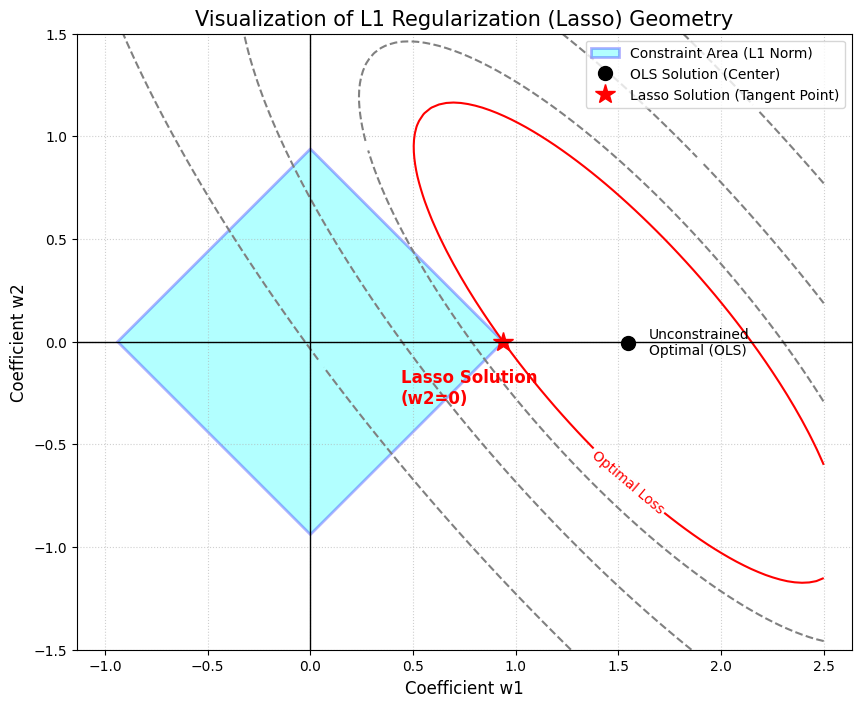

In [4]:
'''
L1 정규화(Lasso)의 기하학적 원리 시각화
이 코드는 상관관계가 있는 두 변수에 대한 회귀 문제를 시뮬레이션하여,
손실 함수(Loss Function)의 등고선이 L1 제약 조건(마름모)과 접하는 과정을 시각화합니다.

주요 단계:
1. 상관관계가 있는 데이터 생성 (타원형 등고선을 만들기 위함)
2. OLS(최소제곱법) 해와 Lasso(L1 규제) 해 계산
3. 파라미터 공간(w1, w2)에서의 RSS(Residual Sum of Squares) 등고선 시각화
4. L1 제약 조건 영역(마름모) 시각화 및 접점 표시
'''

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso
from matplotlib.patches import Polygon

# 1. 데이터 생성 (상관관계가 있는 변수)
np.random.seed(42)
n_samples = 100
# X1과 X2 사이에 상관관계를 주어 등고선을 기울어진 타원형으로 만듦
X1 = np.random.randn(n_samples)
X2 = 0.8 * X1 + np.random.randn(n_samples) * 0.5  # 상관관계 부여
X = np.column_stack([X1, X2])

# 실제 정답 가중치 (w_true): (1.5, 0) -> 즉, 두 번째 변수는 중요하지 않음 (Sparsity 유도 목표)
w_true = np.array([1.5, 0])
y = X.dot(w_true) + np.random.randn(n_samples) * 0.2

# 2. 모델 학습
# OLS (규제 없음, 타원의 중심)
ols = LinearRegression(fit_intercept=False) # 시각화 편의를 위해 절편 제외
ols.fit(X, y)
w_ols = ols.coef_

# Lasso (적절한 alpha를 설정하여 0이 되는 지점 찾기)
# alpha를 조절하여 제약조건의 크기(t)를 간접적으로 설정
lasso = Lasso(alpha=0.5, fit_intercept=False)
lasso.fit(X, y)
w_lasso = lasso.coef_

# Lasso 해의 L1 Norm 계산 (이것이 마름모의 크기 t가 됨)
t_lasso = np.sum(np.abs(w_lasso))

# 3. 시각화 준비
# 격자 생성
w1_range = np.linspace(-1, 2.5, 100)
w2_range = np.linspace(-1.5, 1.5, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)

# 각 격자점에서의 RSS(Loss) 계산
RSS = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w_curr = np.array([W1[i, j], W2[i, j]])
        y_pred = X.dot(w_curr)
        RSS[i, j] = np.sum((y - y_pred)**2)

# 접점에서의 RSS 값 (Lasso 해에서의 Loss)
rss_lasso = np.sum((y - X.dot(w_lasso))**2)

# 4. 그래프 그리기
plt.figure(figsize=(10, 8))

# 배경 등고선 (Loss Function)
# Lasso 해를 지나가는 등고선(접하는 순간)을 포함하여 여러 레벨 표시
levels = [rss_lasso, rss_lasso * 1.5, rss_lasso * 3, rss_lasso * 6]
contours = plt.contour(W1, W2, RSS, levels=levels, colors=['red', 'gray', 'gray', 'gray'], linestyles=['-', '--', '--', '--'])
plt.clabel(contours, inline=True, fontsize=10, fmt={rss_lasso: 'Optimal Loss', levels[1]: '', levels[2]: '', levels[3]: ''})

# L1 제약 조건 (마름모)
# |w1| + |w2| <= t_lasso
diamond_x = [t_lasso, 0, -t_lasso, 0]
diamond_y = [0, t_lasso, 0, -t_lasso]
diamond = Polygon(list(zip(diamond_x, diamond_y)), facecolor='cyan', alpha=0.3, edgecolor='blue', linewidth=2, label='Constraint Area (L1 Norm)')
plt.gca().add_patch(diamond)

# OLS 해 (타원의 중심)
plt.plot(w_ols[0], w_ols[1], 'ko', markersize=10, label='OLS Solution (Center)')
plt.text(w_ols[0]+0.1, w_ols[1], 'Unconstrained\nOptimal (OLS)', fontsize=10, verticalalignment='center')

# Lasso 해 (접점)
plt.plot(w_lasso[0], w_lasso[1], 'r*', markersize=15, label='Lasso Solution (Tangent Point)')
plt.text(w_lasso[0]-0.5, w_lasso[1]-0.3, 'Lasso Solution\n(w2=0)', color='red', fontsize=12, fontweight='bold')

# 축 및 레이블 설정
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Coefficient w1', fontsize=12)
plt.ylabel('Coefficient w2', fontsize=12)
plt.title('Visualization of L1 Regularization (Lasso) Geometry', fontsize=15)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal') # 가로세로 비율 유지하여 기하학적 왜곡 방지

# 저장
plt.savefig('lasso_visualization.png', dpi=150, bbox_inches='tight')

최적점을 모르는 경우(현실의 대부분의 상황)

c:\Users\brigh\Documents\GitHub\brighteen\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


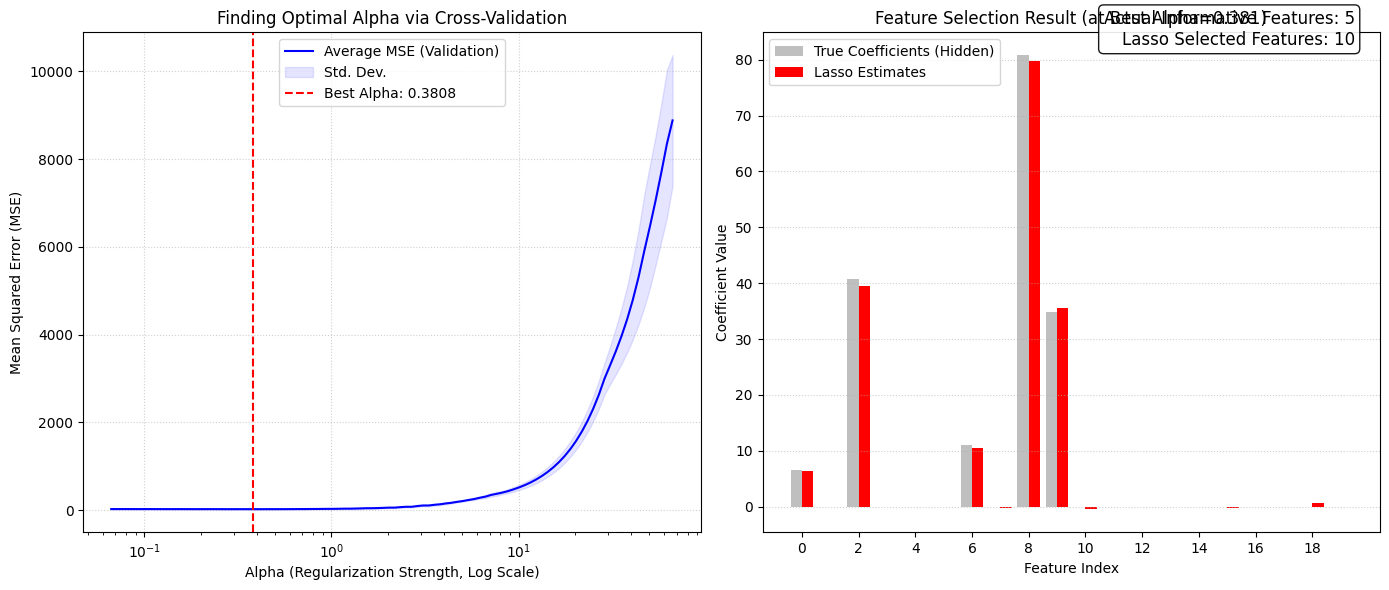

In [1]:
'''
최적점을 모르는 실전 상황에서의 L1 규제 최적화 시각화 (LassoCV)
이 코드는 정답(True Weights)을 모르는 상태에서 교차 검증(Cross Validation)을 통해
최적의 규제 강도(Alpha)를 찾아내고, 그 결과 변수 선택이 어떻게 이루어졌는지 시각화합니다.

주요 단계:
1. 가상의 고차원 데이터 생성 (20개 변수 중 5개만 유효)
2. LassoCV를 사용하여 최적의 Alpha 탐색 (K-Fold 교차 검증)
3. 시각화:
    - Alpha에 따른 검증 오차(MSE) 변화 그래프 (최적 Alpha 도출 과정)
    - 실제 정답 가중치와 Lasso가 추정한 가중치 비교 (변수 선택 결과)
'''

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold

# 1. 데이터 생성 (정답을 모르는 상황 가정)
# n_features=20: 변수가 20개
# n_informative=5: 실제로 의미 있는 변수는 5개뿐 (나머지 15개는 노이즈)
# noise=5.0: 현실적인 데이터 잡음 추가
X, y, coef_true = make_regression(n_samples=100, n_features=20, n_informative=5,
                                  noise=5.0, coef=True, random_state=42)

# 2. LassoCV 모델 학습 (최적의 Alpha 자동 탐색)
# cv=5: 5-Fold Cross Validation (데이터를 5등분해서 검증)
# n_alphas=100: 100개의 다른 Alpha 값을 테스트
lasso_cv = LassoCV(cv=5, random_state=42, n_alphas=100).fit(X, y)

# 최적의 Alpha 값
best_alpha = lasso_cv.alpha_

# 3. 시각화
plt.figure(figsize=(14, 6))

# [Plot 1] Alpha에 따른 MSE(Mean Squared Error) 변화 (검증 곡선)
# lasso_cv.mse_path_ : (n_alphas, n_folds) 형태의 MSE 값들
mse_mean = np.mean(lasso_cv.mse_path_, axis=1) # Fold별 평균 MSE
mse_std = np.std(lasso_cv.mse_path_, axis=1)   # Fold별 MSE 표준편차

plt.subplot(1, 2, 1)
# Alpha는 로그 스케일로 표시
plt.semilogx(lasso_cv.alphas_, mse_mean, 'b-', label='Average MSE (Validation)')
plt.fill_between(lasso_cv.alphas_, mse_mean - mse_std, mse_mean + mse_std,
                 color='blue', alpha=0.1, label='Std. Dev.')
plt.axvline(best_alpha, linestyle='--', color='red', label=f'Best Alpha: {best_alpha:.4f}')

plt.xlabel('Alpha (Regularization Strength, Log Scale)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Finding Optimal Alpha via Cross-Validation')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
# x축 반전: 오른쪽으로 갈수록 Alpha가 작아짐(모델이 복잡해짐)을 표현하기도 하지만, 여기선 기본값 사용

# [Plot 2] True Coefficient vs Lasso Coefficient (변수 선택 결과 확인)
plt.subplot(1, 2, 2)
# 실제 중요 변수 인덱스 확인
true_indices = np.where(coef_true != 0)[0]
# Lasso가 선택한 변수 인덱스 확인
lasso_indices = np.where(lasso_cv.coef_ != 0)[0]

# 막대 그래프로 비교
plt.bar(np.arange(20) - 0.2, coef_true, width=0.4, label='True Coefficients (Hidden)', color='gray', alpha=0.5)
plt.bar(np.arange(20) + 0.2, lasso_cv.coef_, width=0.4, label='Lasso Estimates', color='red')

plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title(f'Feature Selection Result (at Best Alpha={best_alpha:.3f})')
plt.xticks(np.arange(0, 20, 2)) # X축 눈금
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.6)

# 텍스트로 Sparsity 결과 요약 표시
sparsity_text = (f"Actual Informative Features: {len(true_indices)}\n"
                 f"Lasso Selected Features: {len(lasso_indices)}")
plt.text(19.5, np.max(coef_true)*1.1, sparsity_text,
         horizontalalignment='right', verticalalignment='top', fontsize=12,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig('lasso_cv_optimization.png', dpi=150, bbox_inches='tight')